# Modelling wind turbine carbon emissions vs oil, gas, coal, nuclear, and solar generation

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lookbusy1344/Relativity/blob/main/Python/Carbon.ipynb)

> *Inspired by a viral scene in the Paramount+ series **Landman** (2024) in which a character claims that a wind turbine "in its 20-year lifespan, won't offset the carbon footprint of making it."*
> *This claim has been [widely fact-checked and found to be false](https://www.newsweek.com/fact-check-taylor-sheridan-landman-hit-writing-misleads-1995622) — independent researchers and the [Advanced Power Alliance](https://poweralliance.org/2024/11/26/landman-misses-the-facts-on-texas-wind-energy/) put the actual carbon payback period at 5–9 months, not 20 years. This notebook works through the numbers.*

This notebook compares the **cumulative lifecycle CO₂eq emissions** of a 2 MW onshore wind turbine against the equivalent electricity generated from oil, gas (CCGT), coal, nuclear, and utility-scale solar PV, over a 30-year operational life.

## What is modelled

Wind, nuclear, and solar generation all share the same characteristic: a **front-loaded carbon cost** from manufacturing that must be paid off before the source delivers net savings over fossil fuels. This is sometimes called the **carbon payback period**. After payback, these technologies generate electricity at a fraction of fossil fuel emission rates.

Oil, gas (CCGT), and coal have no significant upfront carbon debt — their emissions are purely operational and accumulate linearly from day one. Coal is the most carbon-intensive of the three; gas the least.

The model tracks two quantities over time:

1. **Cumulative tonnes CO₂eq** — running total for each source, shown on a broken y-axis to handle the large difference in scale between fossil and low-carbon sources
2. **Carbon intensity (g CO₂eq/kWh so far)** — how much carbon has been emitted per unit of electricity generated up to that point, on a log scale

## Scope and methodology

All figures are **full lifecycle** estimates (manufacturing, operation, and end-of-life) in kg CO₂eq per MWh, sourced from IPCC AR5/AR6 and NREL harmonized reviews (see *Notes & References* at the bottom). The wind turbine is modelled as a single 2 MW onshore unit operating at the 2023 US fleet-average capacity factor of ~33%. All other sources are modelled as generating the same amount of electricity as that turbine over 30 years.

## Bottom line

- **Wind carbon payback is fast** — the manufacturing carbon debt (~1,560 t CO₂eq) is repaid in roughly **4–5 months**, after which the turbine produces cleaner electricity than oil for the remaining ~29.5 years.
- **Oil emits ~69× more CO₂ over 30 years** than wind — 131,000 t vs 1,900 t for the same energy output.
- **Coal emits ~74× more** than wind — the highest of any source modelled, roughly 8% above oil due to lower combustion efficiency.
- **Gas emits ~45× more** than wind over 30 years — cleaner than oil and coal, but still ~45× the lifecycle total.
- **Nuclear and wind are essentially tied** — nuclear's ~12 g CO₂eq/kWh lifetime average is comparable to wind's ~11 g/kWh; both have upfront manufacturing carbon debts of similar magnitude.
- **Solar PV emits ~4× more than wind** over 30 years (~7,500 t vs ~1,900 t), driven by the energy-intensive panel manufacturing process; still ~11× lower than gas and ~17× lower than oil.
- **The Landman claim is false** — the show's 20-year payback figure is off by a factor of ~50. The turbine spends roughly 98–99% of its operational life in net carbon credit against oil.

In [7]:
# --- Shared parameters and carbon intensities ---
# All figures are lifecycle CO2eq estimates; see Notes & References cell for sources.

TURBINE_CAPACITY_MW = 2.0
CAPACITY_FACTOR = 0.33  # 33.5% US fleet avg in 2023 (EIA); intentionally conservative
HOURS_PER_WEEK = 168
YEARS = 30
WEEKS = YEARS * 52

# Carbon intensities (kg CO2eq per MWh == g CO2eq per kWh)
OIL_KG_PER_MWH = 760.0  # Lifecycle incl. upstream extraction/refining/transport
GAS_KG_PER_MWH = (
    490.0  # CCGT lifecycle incl. upstream methane leakage (IPCC AR5 Annex III)
)
COAL_KG_PER_MWH = 820.0  # IPCC AR5 Annex III median for pulverised coal

# Wind lifecycle phases (NREL/IPCC central estimate ~11 g/kWh total)
WIND_MANUFACTURING_KG_PER_MWH = 9.0  # Upfront: steel, concrete, fibreglass fabrication
WIND_OM_KG_PER_MWH = 1.2  # Operations & maintenance over 30-year life
WIND_DECOMM_KG_PER_MWH = (
    0.8  # End-of-life decommissioning (gross, before recycling credit)
)

# Nuclear lifecycle phases (NREL harmonized median ~12 g/kWh total; Warner & Heath 2012)
NUCLEAR_CONSTRUCTION_KG_PER_MWH = 7.0  # Upfront plant construction & fuel enrichment
NUCLEAR_OM_KG_PER_MWH = 3.0  # Operations including fuel processing & waste handling
NUCLEAR_DECOMM_KG_PER_MWH = 2.0  # Decommissioning and long-term waste disposal

# Solar PV lifecycle phases (utility-scale crystalline silicon; Hsu et al. 2012 ~43 g/kWh total)
SOLAR_MANUFACTURING_KG_PER_MWH = 38.0  # Upfront panel fabrication & balance-of-system
SOLAR_OM_KG_PER_MWH = 3.5  # Operations & maintenance (cleaning, inverter replacement)
SOLAR_DECOMM_KG_PER_MWH = 1.5  # End-of-life panel disposal

coal_t[-1]:       141,838 t
oil_t[-1]:        131,459 t
gas_t[-1]:         84,757 t
solar_t[-1]:        7,438 t
nuclear_t[-1]:      2,076 t
wind_t[-1]:         1,903 t
payback_years: 0.37


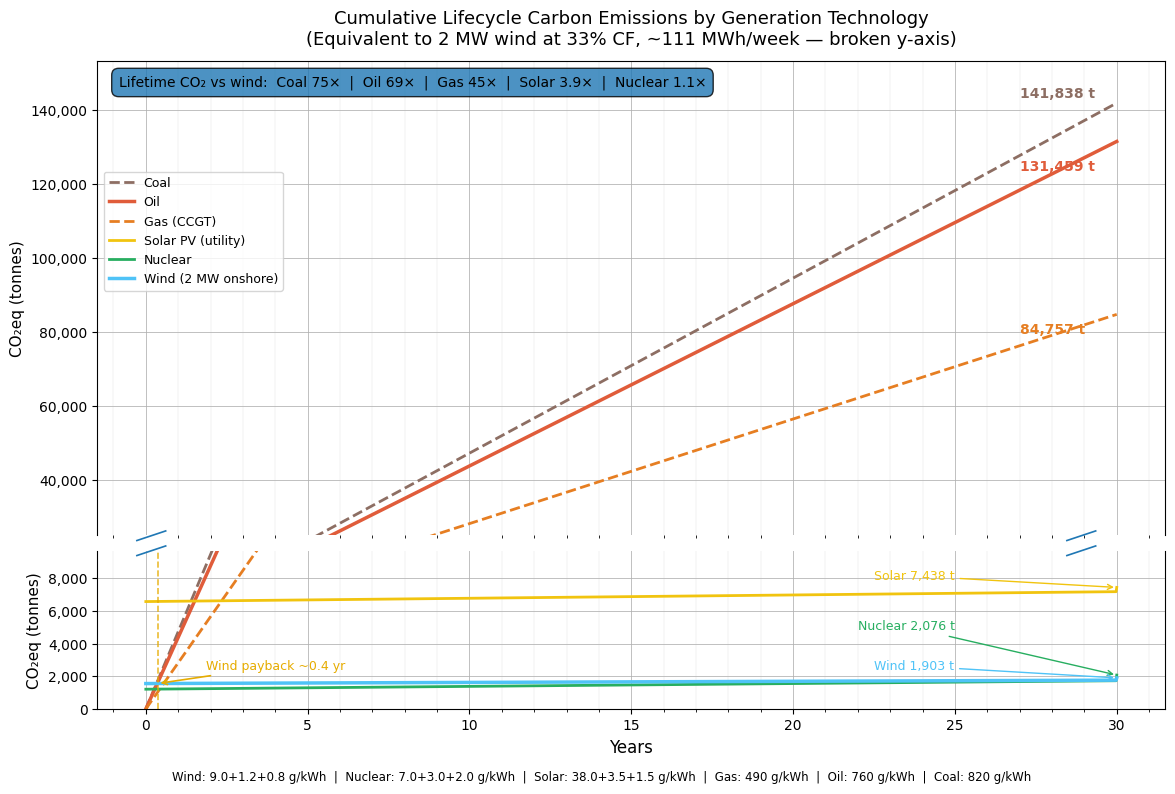

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


weekly_energy_mwh = TURBINE_CAPACITY_MW * CAPACITY_FACTOR * HOURS_PER_WEEK
lifetime_energy_mwh = weekly_energy_mwh * WEEKS

weeks = np.arange(0, WEEKS + 1)

# --- Cumulative carbon series (kg) ---

# Wind: large upfront manufacturing debt, small ongoing O&M, decommissioning at end
wind_cumulative = (
    WIND_MANUFACTURING_KG_PER_MWH * lifetime_energy_mwh
    + WIND_OM_KG_PER_MWH * weekly_energy_mwh * weeks
)
wind_cumulative[WEEKS] += WIND_DECOMM_KG_PER_MWH * lifetime_energy_mwh

# Oil, Gas, Coal: purely operational — no significant upfront carbon cost
oil_cumulative = OIL_KG_PER_MWH * weekly_energy_mwh * weeks
gas_cumulative = GAS_KG_PER_MWH * weekly_energy_mwh * weeks
coal_cumulative = COAL_KG_PER_MWH * weekly_energy_mwh * weeks

# Nuclear: upfront construction debt, ongoing O&M, decommissioning at end
nuclear_cumulative = (
    NUCLEAR_CONSTRUCTION_KG_PER_MWH * lifetime_energy_mwh
    + NUCLEAR_OM_KG_PER_MWH * weekly_energy_mwh * weeks
)
nuclear_cumulative[WEEKS] += NUCLEAR_DECOMM_KG_PER_MWH * lifetime_energy_mwh

# Solar PV: upfront manufacturing debt, ongoing O&M, end-of-life disposal
solar_cumulative = (
    SOLAR_MANUFACTURING_KG_PER_MWH * lifetime_energy_mwh
    + SOLAR_OM_KG_PER_MWH * weekly_energy_mwh * weeks
)
solar_cumulative[WEEKS] += SOLAR_DECOMM_KG_PER_MWH * lifetime_energy_mwh

# Convert to tonnes
wind_t = wind_cumulative / 1000
oil_t = oil_cumulative / 1000
gas_t = gas_cumulative / 1000
coal_t = coal_cumulative / 1000
nuclear_t = nuclear_cumulative / 1000
solar_t = solar_cumulative / 1000

years_axis = weeks / 52

# Wind carbon payback vs oil
above = np.where(oil_t > wind_t)[0]
payback_week = int(above[0]) if len(above) > 0 else None
payback_years = payback_week / 52 if payback_week else None

print(f"coal_t[-1]:    {coal_t[-1]:>10,.0f} t")
print(f"oil_t[-1]:     {oil_t[-1]:>10,.0f} t")
print(f"gas_t[-1]:     {gas_t[-1]:>10,.0f} t")
print(f"solar_t[-1]:   {solar_t[-1]:>10,.0f} t")
print(f"nuclear_t[-1]: {nuclear_t[-1]:>10,.0f} t")
print(f"wind_t[-1]:    {wind_t[-1]:>10,.0f} t")
print(f"payback_years: {payback_years:.2f}" if payback_years else "no payback found")

# --- Broken y-axis ---
# Top panel: coal, oil, gas (high-emission, linear scale)
# Bottom panel: wind, nuclear, solar (low-emission, shows upfront manufacturing debt)
low_max = max(wind_t.max(), solar_t.max(), nuclear_t.max())
y_bot_max = low_max * 1.3
y_top_max = coal_t.max() * 1.08
y_top_min = y_bot_max * 2.6  # gap between panels

COLOR_COAL = "#8d6e63"
COLOR_OIL = "#e05c3a"
COLOR_GAS = "#e67e22"
COLOR_WIND = "#4fc3f7"
COLOR_NUCLEAR = "#27ae60"
COLOR_SOLAR = "#f1c40f"

fig, (ax_top, ax_bot) = plt.subplots(
    2,
    1,
    sharex=True,
    figsize=(12, 8),
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05},
)

for ax in (ax_top, ax_bot):
    ax.grid(True, linewidth=0.7, alpha=0.8)
    ax.grid(True, which="minor", linewidth=0.3, alpha=0.4)
    ax.plot(
        years_axis,
        coal_t,
        color=COLOR_COAL,
        linewidth=2.0,
        linestyle="--",
        label="Coal",
    )
    ax.plot(years_axis, oil_t, color=COLOR_OIL, linewidth=2.5, label="Oil")
    ax.plot(
        years_axis,
        gas_t,
        color=COLOR_GAS,
        linewidth=2.0,
        linestyle="--",
        label="Gas (CCGT)",
    )
    ax.plot(
        years_axis,
        solar_t,
        color=COLOR_SOLAR,
        linewidth=2.0,
        label="Solar PV (utility)",
    )
    ax.plot(years_axis, nuclear_t, color=COLOR_NUCLEAR, linewidth=2.0, label="Nuclear")
    ax.plot(
        years_axis, wind_t, color=COLOR_WIND, linewidth=2.5, label="Wind (2 MW onshore)"
    )

ax_top.set_ylim(y_top_min, y_top_max)
ax_bot.set_ylim(0, y_bot_max)

ax_top.spines["bottom"].set_visible(False)
ax_bot.spines["top"].set_visible(False)
ax_top.tick_params(bottom=False)

# Diagonal break marks
d = 0.012
kwargs = dict(transform=fig.transFigure, clip_on=False, linewidth=1.2)
pos_top = ax_top.get_position()
pos_bot = ax_bot.get_position()
y_break_top = pos_top.y0
y_break_bot = pos_bot.y1
for x in (pos_top.x0, pos_top.x1):
    fig.lines.extend(
        [
            plt.Line2D(
                [x - d, x + d], [y_break_top - d * 0.5, y_break_top + d * 0.5], **kwargs
            ),
            plt.Line2D(
                [x - d, x + d], [y_break_bot - d * 0.5, y_break_bot + d * 0.5], **kwargs
            ),
        ]
    )

# Wind payback marker on bottom panel
if payback_years:
    ax_bot.axvline(
        x=payback_years, color="#e6ac00", linewidth=1.2, linestyle="--", alpha=0.8
    )
    ax_bot.annotate(
        f"Wind payback ~{payback_years:.1f} yr",
        xy=(payback_years, wind_t[payback_week]),
        xytext=(payback_years + 1.5, y_bot_max * 0.25),
        color="#e6ac00",
        fontsize=9,
        arrowprops=dict(arrowstyle="->", color="#e6ac00", lw=1.2),
    )

# End labels — top panel (coal, oil, gas)
ax_top.annotate(
    f"{coal_t[-1]:,.0f} t",
    xy=(30, coal_t[-1]),
    xytext=(27.0, coal_t[-1] * 1.01),
    color=COLOR_COAL,
    fontsize=10,
    fontweight="bold",
)
ax_top.annotate(
    f"{oil_t[-1]:,.0f} t",
    xy=(30, oil_t[-1]),
    xytext=(27.0, oil_t[-1] * 0.94),
    color=COLOR_OIL,
    fontsize=10,
    fontweight="bold",
)
ax_top.annotate(
    f"{gas_t[-1]:,.0f} t",
    xy=(30, gas_t[-1]),
    xytext=(27.0, gas_t[-1] * 0.94),
    color=COLOR_GAS,
    fontsize=10,
    fontweight="bold",
)

# End labels — bottom panel (solar, nuclear, wind)
ax_bot.annotate(
    f"Solar {solar_t[-1]:,.0f} t",
    xy=(30, solar_t[-1]),
    xytext=(22.5, y_bot_max * 0.82),
    color=COLOR_SOLAR,
    fontsize=9,
    arrowprops=dict(arrowstyle="->", color=COLOR_SOLAR, lw=1.0),
)
ax_bot.annotate(
    f"Nuclear {nuclear_t[-1]:,.0f} t",
    xy=(30, nuclear_t[-1]),
    xytext=(22.0, y_bot_max * 0.50),
    color=COLOR_NUCLEAR,
    fontsize=9,
    arrowprops=dict(arrowstyle="->", color=COLOR_NUCLEAR, lw=1.0),
)
ax_bot.annotate(
    f"Wind {wind_t[-1]:,.0f} t",
    xy=(30, wind_t[-1]),
    xytext=(22.5, y_bot_max * 0.25),
    color=COLOR_WIND,
    fontsize=9,
    arrowprops=dict(arrowstyle="->", color=COLOR_WIND, lw=1.0),
)

# Summary callout
ax_top.text(
    0.02,
    0.97,
    f"Lifetime CO\u2082 vs wind:  "
    f"Coal {coal_t[-1] / wind_t[-1]:.0f}\u00d7  |  Oil {oil_t[-1] / wind_t[-1]:.0f}\u00d7  |  Gas {gas_t[-1] / wind_t[-1]:.0f}\u00d7  |  "
    f"Solar {solar_t[-1] / wind_t[-1]:.1f}\u00d7  |  Nuclear {nuclear_t[-1] / wind_t[-1]:.1f}\u00d7",
    transform=ax_top.transAxes,
    ha="left",
    va="top",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.5", alpha=0.8),
)

# Axis labels and formatting
ax_top.set_ylabel("CO\u2082eq (tonnes)", fontsize=11)
ax_bot.set_ylabel("CO\u2082eq (tonnes)", fontsize=11)
ax_bot.set_xlabel("Years", fontsize=12)
ax_top.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax_bot.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax_bot.xaxis.set_major_locator(ticker.MultipleLocator(5))
ax_bot.xaxis.set_minor_locator(ticker.MultipleLocator(1))

ax_top.set_title(
    f"Cumulative Lifecycle Carbon Emissions by Generation Technology\n"
    f"(Equivalent to 2 MW wind at 33% CF, ~{weekly_energy_mwh:.0f} MWh/week — broken y-axis)",
    fontsize=13,
    pad=12,
)

ax_top.legend(fontsize=9, loc="upper left", bbox_to_anchor=(0.0, 0.78))

fig.text(
    0.5,
    0.01,
    f"Wind: {WIND_MANUFACTURING_KG_PER_MWH}+{WIND_OM_KG_PER_MWH}+{WIND_DECOMM_KG_PER_MWH} g/kWh  |  "
    f"Nuclear: {NUCLEAR_CONSTRUCTION_KG_PER_MWH}+{NUCLEAR_OM_KG_PER_MWH}+{NUCLEAR_DECOMM_KG_PER_MWH} g/kWh  |  "
    f"Solar: {SOLAR_MANUFACTURING_KG_PER_MWH}+{SOLAR_OM_KG_PER_MWH}+{SOLAR_DECOMM_KG_PER_MWH} g/kWh  |  "
    f"Gas: {GAS_KG_PER_MWH:.0f} g/kWh  |  Oil: {OIL_KG_PER_MWH:.0f} g/kWh  |  Coal: {COAL_KG_PER_MWH:.0f} g/kWh",
    ha="center",
    fontsize=8.5,
)

plt.subplots_adjust(left=0.08, right=0.97, top=0.91, bottom=0.10, hspace=0.05)

Lifetime wind intensity:    11.00 g/kWh
Lifetime nuclear intensity: 12.00 g/kWh
Lifetime solar intensity:   43.00 g/kWh
Gas (constant):             490.00 g/kWh
Oil (constant):             760.00 g/kWh


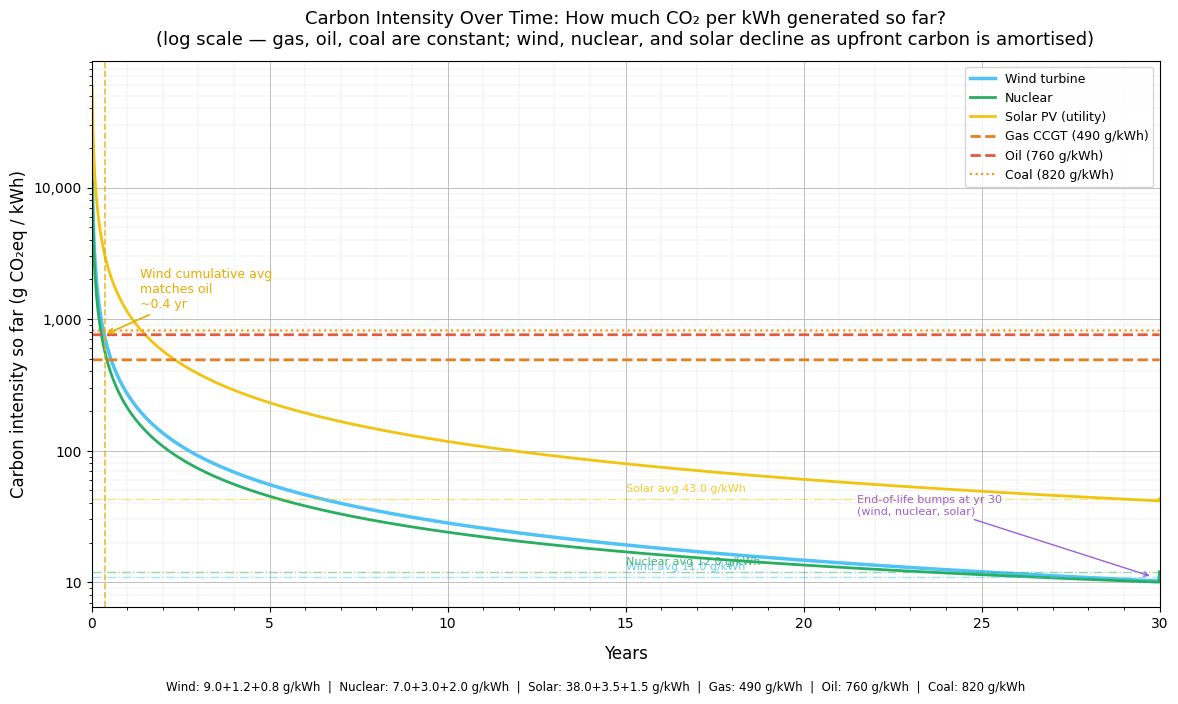

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


weekly_energy_mwh = TURBINE_CAPACITY_MW * CAPACITY_FACTOR * HOURS_PER_WEEK
lifetime_energy_mwh = weekly_energy_mwh * WEEKS

weeks = np.arange(0, WEEKS + 1)

# --- Cumulative carbon series (kg) ---

wind_cumulative_kg = (
    WIND_MANUFACTURING_KG_PER_MWH * lifetime_energy_mwh
    + WIND_OM_KG_PER_MWH * weekly_energy_mwh * weeks
)
wind_cumulative_kg[WEEKS] += WIND_DECOMM_KG_PER_MWH * lifetime_energy_mwh

nuclear_cumulative_kg = (
    NUCLEAR_CONSTRUCTION_KG_PER_MWH * lifetime_energy_mwh
    + NUCLEAR_OM_KG_PER_MWH * weekly_energy_mwh * weeks
)
nuclear_cumulative_kg[WEEKS] += NUCLEAR_DECOMM_KG_PER_MWH * lifetime_energy_mwh

solar_cumulative_kg = (
    SOLAR_MANUFACTURING_KG_PER_MWH * lifetime_energy_mwh
    + SOLAR_OM_KG_PER_MWH * weekly_energy_mwh * weeks
)
solar_cumulative_kg[WEEKS] += SOLAR_DECOMM_KG_PER_MWH * lifetime_energy_mwh

# Cumulative energy generated (MWh) — used as denominator for intensity
cumulative_energy_mwh = weekly_energy_mwh * weeks

# Carbon intensity so far (g CO2eq/kWh == kg/MWh); undefined at week 0 (no energy yet)
with np.errstate(divide="ignore", invalid="ignore"):

    def _intensity(kg):
        return np.where(cumulative_energy_mwh > 0, kg / cumulative_energy_mwh, np.nan)

    wind_intensity = _intensity(wind_cumulative_kg)
    nuclear_intensity = _intensity(nuclear_cumulative_kg)
    solar_intensity = _intensity(solar_cumulative_kg)

# Gas, oil, and coal are constant throughout (no upfront manufacturing credit amortised)
# Their "intensity so far" equals their operational intensity at every point in time.

years_axis = weeks / 52

lifetime_wind_intensity = wind_cumulative_kg[WEEKS] / lifetime_energy_mwh
lifetime_nuclear_intensity = nuclear_cumulative_kg[WEEKS] / lifetime_energy_mwh
lifetime_solar_intensity = solar_cumulative_kg[WEEKS] / lifetime_energy_mwh

print(f"Lifetime wind intensity:    {lifetime_wind_intensity:.2f} g/kWh")
print(f"Lifetime nuclear intensity: {lifetime_nuclear_intensity:.2f} g/kWh")
print(f"Lifetime solar intensity:   {lifetime_solar_intensity:.2f} g/kWh")
print(f"Gas (constant):             {GAS_KG_PER_MWH:.2f} g/kWh")
print(f"Oil (constant):             {OIL_KG_PER_MWH:.2f} g/kWh")

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 7))

COLOR_OIL = "#e05c3a"
COLOR_GAS = "#e67e22"
COLOR_COAL = "#ff8f00"
COLOR_WIND = "#4fc3f7"
COLOR_NUCLEAR = "#27ae60"
COLOR_SOLAR = "#f1c40f"

# Declining intensity curves for technologies with upfront carbon debt (plot from week 1)
ax.semilogy(
    years_axis[1:],
    wind_intensity[1:],
    color=COLOR_WIND,
    linewidth=2.5,
    label="Wind turbine",
)
ax.semilogy(
    years_axis[1:],
    nuclear_intensity[1:],
    color=COLOR_NUCLEAR,
    linewidth=2.0,
    label="Nuclear",
)
ax.semilogy(
    years_axis[1:],
    solar_intensity[1:],
    color=COLOR_SOLAR,
    linewidth=2.0,
    label="Solar PV (utility)",
)

# Constant horizontal lines for operational-only sources
ax.semilogy(
    years_axis[1:],
    np.full(WEEKS, GAS_KG_PER_MWH),
    color=COLOR_GAS,
    linewidth=2.0,
    linestyle="--",
    label=f"Gas CCGT ({GAS_KG_PER_MWH:.0f} g/kWh)",
)
ax.semilogy(
    years_axis[1:],
    np.full(WEEKS, OIL_KG_PER_MWH),
    color=COLOR_OIL,
    linewidth=2.0,
    linestyle="--",
    label=f"Oil ({OIL_KG_PER_MWH:.0f} g/kWh)",
)
ax.semilogy(
    years_axis[1:],
    np.full(WEEKS, COAL_KG_PER_MWH),
    color=COLOR_COAL,
    linewidth=1.5,
    linestyle=":",
    label=f"Coal ({COAL_KG_PER_MWH:.0f} g/kWh)",
)

# Lifetime average reference lines
for val, color, label in [
    (
        lifetime_wind_intensity,
        COLOR_WIND,
        f"Wind avg {lifetime_wind_intensity:.1f} g/kWh",
    ),
    (
        lifetime_nuclear_intensity,
        COLOR_NUCLEAR,
        f"Nuclear avg {lifetime_nuclear_intensity:.1f} g/kWh",
    ),
    (
        lifetime_solar_intensity,
        COLOR_SOLAR,
        f"Solar avg {lifetime_solar_intensity:.1f} g/kWh",
    ),
]:
    ax.axhline(y=val, color=color, linewidth=1.0, linestyle="-.", alpha=0.5)
    ax.text(
        0.5,
        val * 1.13,
        label,
        color=color,
        fontsize=8,
        alpha=0.85,
        transform=ax.get_yaxis_transform(),
    )

# Mark where wind cumulative intensity first drops below oil
crossover = next((w for w in weeks[1:] if wind_intensity[w] <= OIL_KG_PER_MWH), None)
if crossover:
    crossover_yr = crossover / 52
    ax.axvline(
        x=crossover_yr, color="#e6ac00", linewidth=1.2, linestyle="--", alpha=0.8
    )
    ax.annotate(
        f"Wind cumulative avg\nmatches oil\n~{crossover_yr:.1f} yr",
        xy=(crossover_yr, OIL_KG_PER_MWH),
        xytext=(crossover_yr + 1.0, OIL_KG_PER_MWH * 1.6),
        color="#e6ac00",
        fontsize=9,
        arrowprops=dict(arrowstyle="->", color="#e6ac00", lw=1.2),
    )

# Decommissioning blips at year 30 (wind, nuclear, solar all show a small uptick)
ax.annotate(
    "End-of-life bumps at yr 30\n(wind, nuclear, solar)",
    xy=(29.8, wind_intensity[WEEKS]),
    xytext=(21.5, lifetime_wind_intensity * 3.0),
    color="#9c5fd6",
    fontsize=8,
    arrowprops=dict(arrowstyle="->", color="#9c5fd6", lw=1.0),
)

ax.set_xlabel("Years", fontsize=12, labelpad=10)
ax.set_ylabel("Carbon intensity so far (g CO\u2082eq / kWh)", fontsize=12)
ax.set_title(
    "Carbon Intensity Over Time: How much CO\u2082 per kWh generated so far?\n"
    "(log scale — gas, oil, coal are constant; wind, nuclear, and solar decline as upfront carbon is amortised)",
    fontsize=13,
    pad=12,
)
ax.set_xlim(0, 30)
ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(1))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.grid(True, linewidth=0.7, alpha=0.8)
ax.grid(True, which="minor", linewidth=0.3, alpha=0.4)
ax.legend(fontsize=9, loc="upper right")

fig.text(
    0.5,
    0.01,
    f"Wind: {WIND_MANUFACTURING_KG_PER_MWH}+{WIND_OM_KG_PER_MWH}+{WIND_DECOMM_KG_PER_MWH} g/kWh  |  "
    f"Nuclear: {NUCLEAR_CONSTRUCTION_KG_PER_MWH}+{NUCLEAR_OM_KG_PER_MWH}+{NUCLEAR_DECOMM_KG_PER_MWH} g/kWh  |  "
    f"Solar: {SOLAR_MANUFACTURING_KG_PER_MWH}+{SOLAR_OM_KG_PER_MWH}+{SOLAR_DECOMM_KG_PER_MWH} g/kWh  |  "
    f"Gas: {GAS_KG_PER_MWH:.0f} g/kWh  |  Oil: {OIL_KG_PER_MWH:.0f} g/kWh  |  Coal: {COAL_KG_PER_MWH:.0f} g/kWh",
    ha="center",
    fontsize=8.5,
)

plt.subplots_adjust(left=0.08, right=0.97, top=0.91, bottom=0.13)

## Wind vs Nuclear: A Closer Look

The charts show wind sitting *above* nuclear for almost the entire 30-year period, yet nuclear ends up with a *higher* lifetime total. This apparent contradiction is worth unpacking.

### Why wind appears above nuclear on the charts

Both technologies carry an upfront manufacturing carbon debt, but the composition differs:

| Phase | Wind | Nuclear |
|---|---|---|
| Upfront (manufacturing / construction) | 9.0 g/kWh | 7.0 g/kWh |
| Ongoing O&M | 1.2 g/kWh | 3.0 g/kWh |
| End-of-life | 0.8 g/kWh | 2.0 g/kWh |
| **Lifetime total** | **11.0 g/kWh** | **12.0 g/kWh** |

Wind's larger upfront debt (~1,557 t vs nuclear's ~1,211 t) means it starts higher and remains above nuclear throughout the operational life. Nuclear's higher ongoing O&M rate closes the gap steadily — by year 30, the two are only ~35 t apart. Then nuclear's much larger decommissioning cost (+346 t vs wind's +138 t) flips it above wind in the final accounting. The "crossing point" is effectively at the decommissioning step, not during operations.

### Nuclear decommissioning is genuinely uncertain

The 2.0 g/kWh figure used for nuclear end-of-life covers physical plant dismantling and long-term spent fuel management. Unlike wind decommissioning (which largely follows established practice and recovers ~90% of structural steel), nuclear decommissioning has significant uncertainties:

- **Timescale**: full decommissioning of a nuclear plant typically takes 40–60 years post-shutdown, with regulatory and funding risks throughout.
- **Spent fuel**: no country has yet commissioned a permanent geological repository for high-level radioactive waste. Long-term disposal costs are still being estimated.
- **Historical underestimation**: several UK and US decommissioning projects have come in substantially over their original cost estimates.

If the true end-of-life cost is higher than 2.0 g/kWh, nuclear's lifetime total grows accordingly — widening its gap over wind.

### The IPCC range for nuclear is uniquely wide

The IPCC AR5 lifecycle range for nuclear is **3.7–110 g CO₂eq/kWh** — far wider than wind (7–20) or solar (18–180). The two biggest drivers of this spread are:

1. **Uranium enrichment method**: gaseous diffusion enrichment (used in older US and UK plants) consumes roughly 50× more electricity than modern centrifuge enrichment. At the grid carbon intensities typical when those plants were built, this dominates the lifecycle total. Centrifuge-enriched nuclear (France, most modern plants) comes in around 4–8 g/kWh; diffusion-enriched plants can exceed 40 g/kWh.

2. **Grid carbon intensity at build time**: the embodied carbon in steel, concrete, and components depends on the electricity grid when the plant was constructed.

The 12 g/kWh median used in this model is appropriate for a modern Western reactor using centrifuge enrichment. Using 6 g/kWh (a reasonable figure for French-style nuclear) would place nuclear clearly below wind for the entire 30-year period. Using 20–25 g/kWh (diffusion-enriched, older grid) would place it well above wind.

### Bottom line on wind vs nuclear

At the NREL/IPCC central estimates used here, the two technologies are effectively **carbon-equivalent** — 11 vs 12 g CO₂eq/kWh lifetime, a difference smaller than the uncertainty in either figure. Both are roughly 40–70× lower than gas and oil. The more practically significant difference between them is not lifecycle carbon but rather construction time, cost, water use, land use, and grid dispatchability.

## Notes on Assumptions

All assumptions used in this model are realistic and grounded in well-sourced published data. Lifecycle figures for all six sources — wind, nuclear, solar PV, gas (CCGT), oil, and coal — are drawn from IPCC AR5/AR6 Annex III and NREL harmonized systematic reviews, which apply consistent methodology across studies to remove artefacts from differing assumptions. The wind capacity factor is drawn directly from 2023 EIA actuals. No figures have been cherry-picked to favour any source.

### Capacity factor — 33%
The 2023 US fleet-wide average for land-based wind was **33.5%**, the lowest in eight years (down from 35.9% in 2022 due to below-normal wind speeds in H1 2023). The 33% figure used here is intentionally slightly below the long-run average to produce a conservative result.

### Wind turbine lifecycle emissions — 11 g CO₂eq/kWh total
All three wind figures together match the NREL harmonized median and IPCC SRREN central estimate for 2 MW onshore wind:

| Phase | This model | IPCC range | NREL harmonized median |
|---|---|---|---|
| Manufacturing (upfront) | 9.0 g/kWh | 7–20 g/kWh | ~11 g/kWh total |
| O&M (ongoing) | 1.2 g/kWh | ~0.5–2 g/kWh | — |
| Decommissioning (end-of-life) | 0.8 g/kWh | ~0.3–0.8 g/kWh | — |
| **Total** | **11.0 g/kWh** | **7–20+ g/kWh** | **~11 g/kWh** |

Manufacturing dominates at ~82% of the total, consistent with published LCA breakdowns. The decommissioning figure is a gross estimate; partial recycling of structural steel (~90% recyclable) would reduce it toward ~0.2–0.4 g/kWh net.

### Natural gas (CCGT) — 490 g CO₂eq/kWh
This is the **IPCC AR5 Annex III lifecycle median** for combined-cycle gas turbine (CCGT) generation (range 410–650 g/kWh). The figure includes:
- Direct combustion CO₂: ~370–400 g/kWh
- Upstream methane leakage, processing, and transport: ~80–100 g/kWh

Gas has no significant upfront manufacturing carbon debt — effectively all of its emissions are operational and accumulate linearly from day one, unlike wind, nuclear, and solar. Note that actual methane leakage rates vary considerably by region and infrastructure; higher leakage would push the lifecycle figure above 490 g/kWh.

### Coal — 820 g CO₂eq/kWh
**IPCC AR5 Annex III median** value for pulverised coal, full lifecycle (range 740–910 g/kWh). Like oil and gas, coal has no significant upfront manufacturing carbon cost — its emissions are purely operational. At 820 g CO₂eq/kWh, coal is the highest-emitting source modelled, approximately 74× the lifetime total of wind. The higher intensity relative to oil reflects coal's lower combustion efficiency and higher carbon content per unit of energy. The lifecycle range (740–910 g/kWh) reflects differences in plant efficiency, coal rank (lignite vs bituminous), and upstream mining and transport emissions.

### Nuclear lifecycle emissions — 12 g CO₂eq/kWh total
Based on the **NREL harmonized median** (Warner & Heath 2012) and IPCC AR5 Annex III central estimate. Nuclear has a significant upfront carbon cost in plant construction and uranium enrichment, followed by low ongoing emissions:

| Phase | This model | IPCC range |
|---|---|---|
| Construction & fuel enrichment (upfront) | 7.0 g/kWh | — |
| Operations & fuel processing (ongoing) | 3.0 g/kWh | — |
| Decommissioning & waste disposal (end-of-life) | 2.0 g/kWh | — |
| **Total** | **12.0 g/kWh** | **3.7–110 g/kWh** |

The wide IPCC range reflects differences in uranium enrichment method (centrifuge vs. diffusion), grid carbon intensity at build time, and plant lifetime assumptions. The 12 g/kWh median is consistent with modern Western plants using centrifuge enrichment.

### Solar PV lifecycle emissions — 43 g CO₂eq/kWh total
Based on the **NREL harmonized median for utility-scale crystalline silicon** (Hsu et al. 2012) and IPCC AR5 Annex III. Like wind and nuclear, solar has an upfront manufacturing carbon cost:

| Phase | This model | IPCC range |
|---|---|---|
| Panel fabrication & balance-of-system (upfront) | 38.0 g/kWh | — |
| Operations & maintenance (ongoing) | 3.5 g/kWh | — |
| End-of-life panel disposal | 1.5 g/kWh | — |
| **Total** | **43.0 g/kWh** | **18–180 g/kWh** |

Manufacturing dominates (~88% of total), primarily driven by the energy intensity of silicon purification and cell fabrication. The wide IPCC range reflects the large variation in grid carbon intensity where panels are manufactured (panels made in China with coal-heavy grids have higher embodied carbon than those made in Europe). This model uses the NREL harmonized median, which corrects for methodological inconsistencies across studies.

### Oil-fired electricity — 760 g CO₂eq/kWh
This is a **full lifecycle** estimate including direct combustion CO₂ (~700 g/kWh) plus a ~9% upstream uplift for extraction, refining, and transport of the fuel. The IPCC AR5 lifecycle median for oil-fired generation is ~650 g CO₂eq/kWh; the higher figure here reflects typical US plant efficiencies and EIA-reported emission rates for petroleum-fired generation.

All figures are lifecycle estimates, making them directly comparable.

---

## References

**Sources by technology:**
- **Wind**: refs 3, 4, 5, 10, 11
- **Nuclear**: refs 4, 6, 7, 8
- **Solar PV**: refs 4, 6, 7, 9
- **Gas (CCGT)**: refs 4, 6, 7
- **Oil**: refs 4, 6, 7
- **Coal**: refs 4, 6, 7

1. **U.S. EIA** (2024). *Wind turbines provided 10% of total U.S. electricity generation in 2023*. EIA Today in Energy.  
   EIA data shows 2023 fleet-wide land-based wind capacity factor of 33.5%.

2. **U.S. EIA** (2024). *Electric Power Monthly, Table 6.07.B — Capacity Factors for Utility Scale Generators Not Primarily Using Fossil Fuels*.  
   U.S. Energy Information Administration. https://www.eia.gov/electricity/monthly/

3. **NREL** (2012). Dolan, S.L. & Heath, G.A. *Life Cycle Greenhouse Gas Emissions of Utility-Scale Wind Power: Systematic Review and Harmonization*. Journal of Industrial Ecology, 16(S1), S136–S154.  
   DOI: 10.1111/j.1530-9290.2012.00464.x  
   Harmonized median for onshore wind: ~11 g CO₂eq/kWh.

4. **NREL** (2021). *Life Cycle Greenhouse Gas Emissions from Electricity Generation: Update*.  
   NREL Technical Report NREL/TP-6A20-80580. https://docs.nrel.gov/docs/fy21osti/80580.pdf  
   Covers all generation technologies — wind, solar, nuclear, gas, oil, and coal — with updated harmonized lifecycle estimates.

5. **IPCC** (2012). *Special Report on Renewable Energy Sources and Climate Change Mitigation (SRREN)*, Chapter 7: Wind Energy.  
   Cambridge University Press. https://www.ipcc.ch/site/assets/uploads/2018/03/Chapter-7-Wind-Energy-1.pdf  
   Onshore wind lifecycle: 7–15 g CO₂eq/kWh (central estimate ~11 g/kWh).

6. **IPCC** (2014). *Fifth Assessment Report (AR5), Working Group III, Annex III: Technology-Specific Cost and Performance Parameters*.  
   Table A.III.2 provides lifecycle medians and ranges for all generation technologies: Coal 820 g CO₂eq/kWh (range 740–910); Oil ~650 g CO₂eq/kWh; Gas (CCGT) ~490 g CO₂eq/kWh (range 410–650); Nuclear ~12 g CO₂eq/kWh (range 3.7–110); Solar PV ~48 g CO₂eq/kWh (range 18–180); Wind ~11 g CO₂eq/kWh (range 7–56).  
   https://www.ipcc.ch/site/assets/uploads/2018/02/ipcc_wg3_ar5_annex-iii.pdf

7. **IPCC** (2022). *Sixth Assessment Report (AR6), Working Group III, Chapter 6: Energy Systems*.  
   Updated lifecycle emission factors for all electricity generation technologies, broadly consistent with AR5 Annex III for mature technologies.  
   https://www.ipcc.ch/report/ar6/wg3/chapter/chapter-6/

8. **NREL** (2012). Warner, E.S. & Heath, G.A. *Life Cycle Greenhouse Gas Emissions of Nuclear Electricity Generation: Systematic Review and Harmonization*. Journal of Industrial Ecology, 16(S1), S73–S92.  
   DOI: 10.1111/j.1530-9290.2012.00472.x  
   Harmonized median for nuclear: ~12 g CO₂eq/kWh (range 3.7–110 g/kWh).

9. **NREL** (2012). Hsu, D.D. et al. *Life Cycle Greenhouse Gas Emissions of Crystalline Silicon Photovoltaic Electricity Generation: Systematic Review and Harmonization*. Journal of Industrial Ecology, 16(S1), S122–S135.  
   DOI: 10.1111/j.1530-9290.2011.00439.x  
   Harmonized median for utility-scale crystalline silicon PV: ~44 g CO₂eq/kWh (range 18–180 g/kWh).

10. **NREL** (2025). *Recycling Wind Energy Systems in the United States*.  
    NREL Technical Report NREL/TP-5000-87970. https://docs.nrel.gov/docs/fy25osti/87970.pdf  
    Decommissioning and recycling credit analysis for end-of-life wind turbines.

11. **DOE** (2024). *Land-Based Wind Market Report: 2024 Edition*.  
    U.S. Department of Energy, Office of Energy Efficiency & Renewable Energy.  
    https://www.energy.gov/eere/wind/wind-market-reports-2024-edition